## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest, f_classif,
    mutual_info_classif,
    SelectFromModel,
    RFE,
    SequentialFeatureSelector,
    VarianceThreshold
)
from sklearn.metrics import mutual_info_score

# Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Preprocesado y evaluacion
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('ggplot')

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


---
## Paso 1: Carga y preprocesado

In [3]:
# Cargamos el dataset de credit scoring
df = pd.read_csv("data/credit_npo.csv")

print(f"Shape original: {df.shape}")
print(f"\nNulos por columna:")
print(df.isnull().sum())
print(f"\nTarget:")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nEl dataset esta muy desbalanceado ({df['SeriousDlqin2yrs'].mean()*100:.1f}% de positivos)")
print("-> Usaremos balanced_accuracy como metrica")

Shape original: (12537, 11)

Nulos por columna:
SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Target:
SeriousDlqin2yrs
0    11673
1      864
Name: count, dtype: int64

El dataset esta muy desbalanceado (6.9% de positivos)
-> Usaremos balanced_accuracy como metrica


In [4]:
# Eliminamos filas con nulos (como pide el enunciado)
df = df.dropna().reset_index(drop=True)
print(f"Shape despues de eliminar nulos: {df.shape}")

target = 'SeriousDlqin2yrs'

Shape despues de eliminar nulos: (11816, 11)


In [5]:
# Convertimos las features NumberOf... a categoricas con 2-3 niveles
# Criterio: 0 = ninguno, 1 = entre 1 y 2, 2 = 3 o mas
# Estas features tienen muchos ceros y luego valores altos muy poco frecuentes

cols_to_cat = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

for col in cols_to_cat:
    df[col] = df[col].apply(lambda x: 0 if x == 0 else (1 if x <= 2 else 2)).astype(int)

# NumberOfOpenCreditLinesAndLoans lo bucketo en 3 rangos porque toma valores mas variados
df['NumberOfOpenCreditLinesAndLoans'] = pd.cut(
    df['NumberOfOpenCreditLinesAndLoans'],
    bins=[-1, 4, 9, 100],
    labels=[0, 1, 2]
).astype(int)

# Verificamos
print("Distribucion de las columnas convertidas:")
for col in cols_to_cat + ['NumberOfOpenCreditLinesAndLoans']:
    print(f"  {col[:35]:35s}: {df[col].value_counts().sort_index().to_dict()}")

Distribucion de las columnas convertidas:
  NumberOfTime30-59DaysPastDueNotWors: {0: 9818, 1: 1751, 2: 247}
  NumberOfTimes90DaysLate            : {0: 11156, 1: 536, 2: 124}
  NumberOfTime60-89DaysPastDueNotWors: {0: 11206, 1: 563, 2: 47}
  NumberRealEstateLoansOrLines       : {0: 4233, 1: 6734, 2: 849}
  NumberOfDependents                 : {0: 6413, 1: 4182, 2: 1221}
  NumberOfOpenCreditLinesAndLoans    : {0: 2350, 1: 5078, 2: 4388}


In [6]:
# Definimos tipos de features
features_num = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']
features_cat = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberRealEstateLoansOrLines',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfDependents'
]
features_all = features_num + features_cat

print(f"Features numericas: {features_num}")
print(f"Features categoricas: {features_cat}")

# Split train/test (estratificado por el target desbalanceado)
X = df[features_all]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nBalance en train: {y_train.mean()*100:.1f}% positivos")

Features numericas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']
Features categoricas: ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberRealEstateLoansOrLines', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']

X_train: (9452, 10)
X_test:  (2364, 10)

Balance en train: 7.0% positivos


---
## Paso 2: MiniEDA + Selección de Features

Aplico los 6 métodos pedidos para obtener 6 listas de features.

### 2.1 Análisis visual + correlación + umbral de varianza

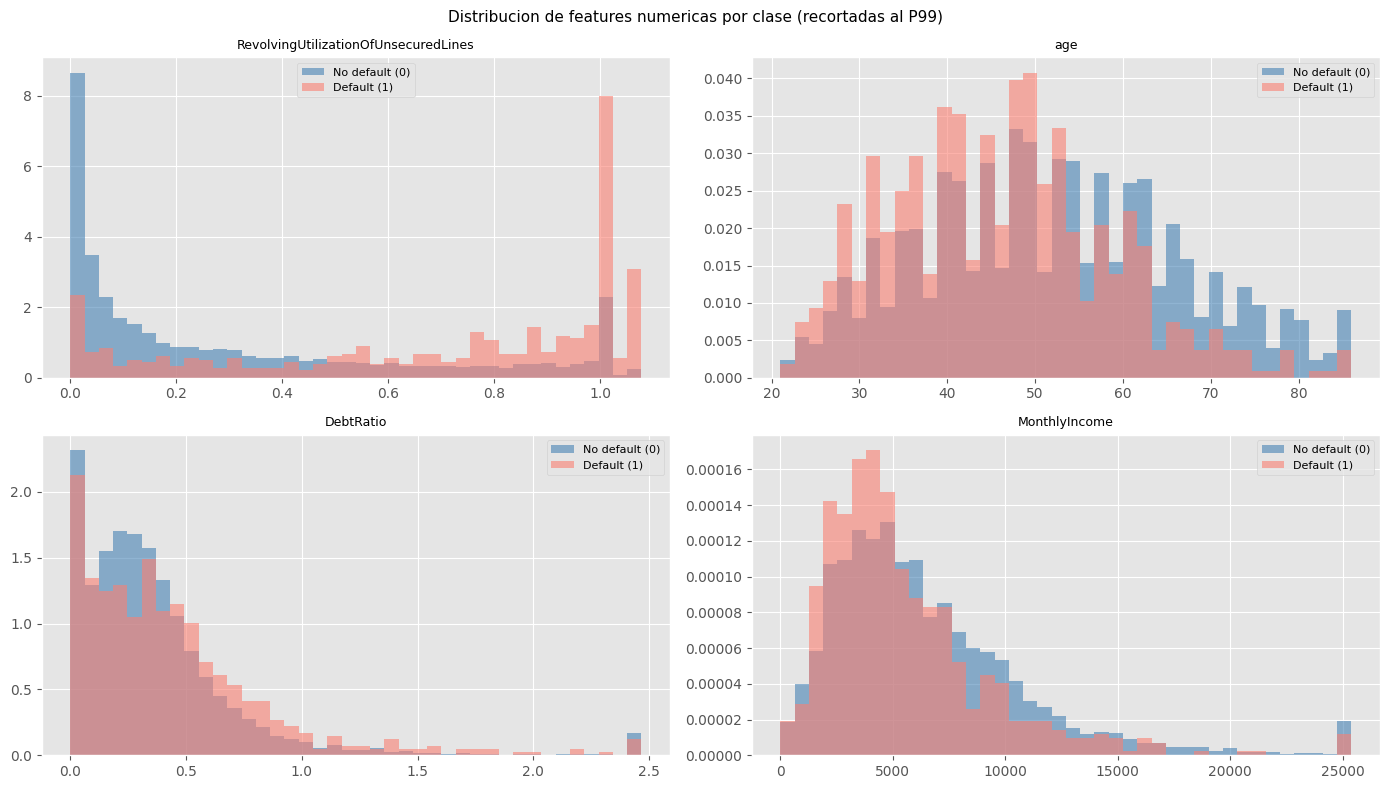

In [7]:
# Dataset de train combinado para análisis
df_train = pd.concat([X_train, y_train], axis=1)

# Distribución de features numéricas por clase target
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, features_num):
    # Limitamos el eje x para que no se disparen los outliers
    q99 = X_train[col].quantile(0.99)
    datos = X_train[col].clip(upper=q99)
    ax.hist(datos[y_train == 0], alpha=0.6, bins=40, label='No default (0)', color='steelblue', density=True)
    ax.hist(datos[y_train == 1], alpha=0.6, bins=40, label='Default (1)',    color='salmon',    density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=8)
plt.suptitle("Distribucion de features numericas por clase (recortadas al P99)", fontsize=11)
plt.tight_layout()
plt.show()

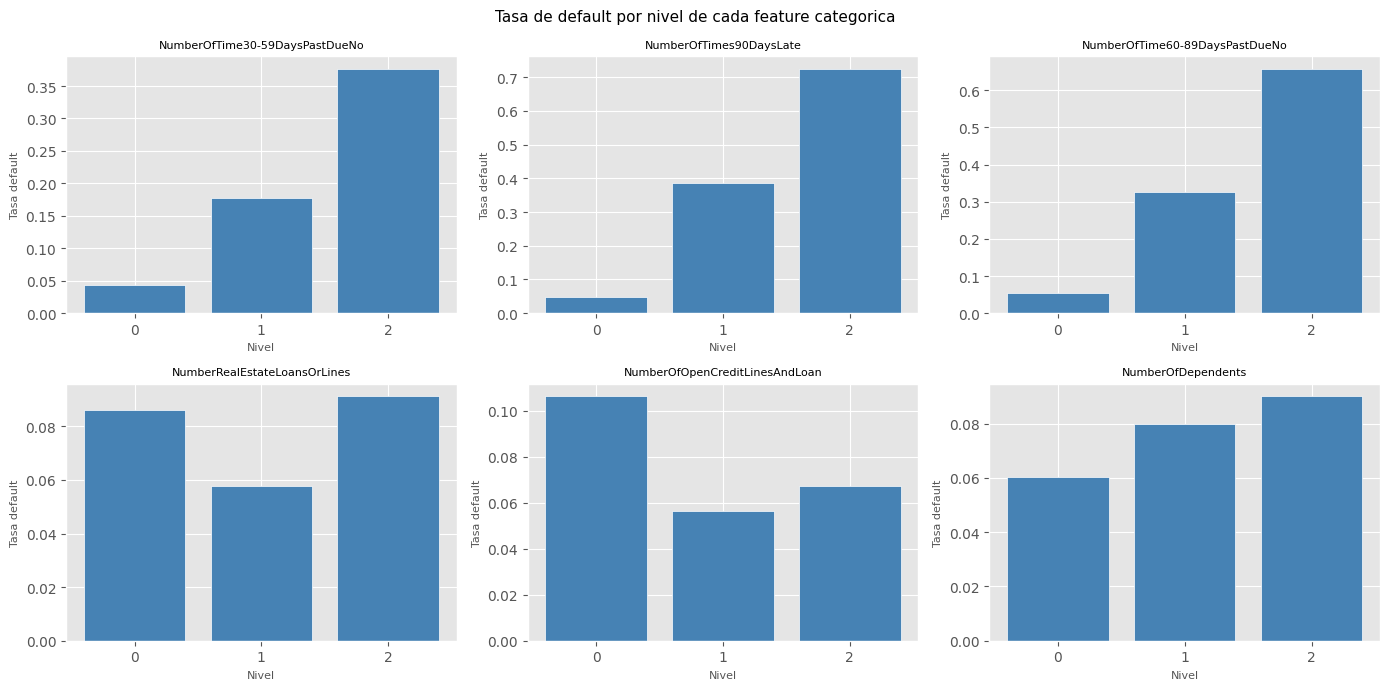

In [8]:
# Tasa de default por nivel para las features categóricas
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, features_cat):
    tasa = df_train.groupby(col)[target].mean()
    ax.bar(tasa.index, tasa.values, color='steelblue', edgecolor='white')
    ax.set_title(col[:30], fontsize=8)
    ax.set_xlabel('Nivel', fontsize=8)
    ax.set_ylabel('Tasa default', fontsize=8)
    ax.set_xticks([0, 1, 2])
plt.suptitle("Tasa de default por nivel de cada feature categorica", fontsize=11)
plt.tight_layout()
plt.show()

Correlacion (|Pearson|) features numericas con target:
RevolvingUtilizationOfUnsecuredLines    0.2775
age                                     0.1053
MonthlyIncome                           0.0254
DebtRatio                               0.0001
Name: SeriousDlqin2yrs, dtype: float64


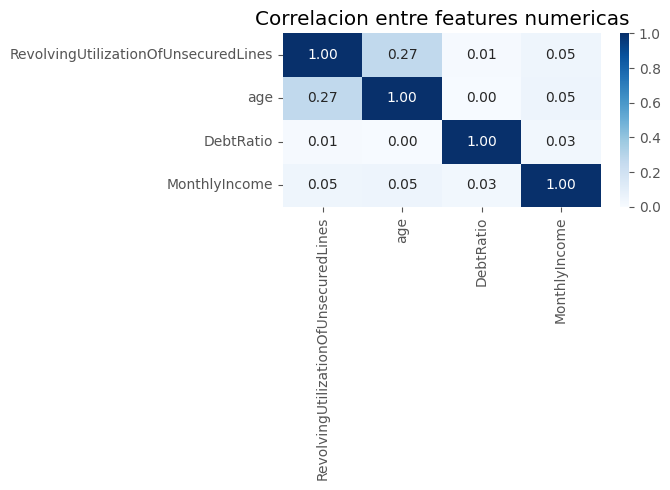

In [9]:
# Correlación de features numéricas con el target
corr_con_target = df_train[features_num + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)
print("Correlacion (|Pearson|) features numericas con target:")
print(corr_con_target.round(4))

# Heatmap inter-features para detectar colinealidad
plt.figure(figsize=(7, 5))
sns.heatmap(
    X_train[features_num].corr().abs(),
    annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1
)
plt.title("Correlacion entre features numericas")
plt.tight_layout()
plt.show()

In [10]:
# MI (Mutual Information) de features categóricas con el target
# Para ver su relación con la variable objetivo
print("Mutual Information de features categoricas con el target:")
mi_cat_manual = {}
for col in features_cat:
    mi = mutual_info_score(X_train[col], y_train)
    mi_cat_manual[col] = mi
    print(f"  {col[:40]:40s}: {mi:.5f}")

# Umbral de varianza en features numericas (por si alguna tiene varianza casi cero)
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train[features_num])
print(f"\nFeatures numericas con varianza > 0.01: {list(vt.get_feature_names_out())}")

Mutual Information de features categoricas con el target:
  NumberOfTime30-59DaysPastDueNotWorse    : 0.02284
  NumberOfTimes90DaysLate                 : 0.03505
  NumberOfTime60-89DaysPastDueNotWorse    : 0.02013
  NumberRealEstateLoansOrLines            : 0.00157
  NumberOfOpenCreditLinesAndLoans         : 0.00245
  NumberOfDependents                      : 0.00096

Features numericas con varianza > 0.01: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']


In [11]:
# LISTA 1: basada en el analisis visual + correlacion + MI
# Observaciones:
# - Las 3 features de "PastDue" tienen las MI más altas -> las incluyo todas
# - RevolvingUtilizationOfUnsecuredLines tiene la correlacion mas alta con el target
# - age tiene correlacion moderada y se aprecia diferencia en el histograma
# - DebtRatio y MonthlyIncome tienen correlacion muy baja, quizas incluir uno
# - NumberRealEstateLoansOrLines, NumberOfOpenCreditLinesAndLoans y NumberOfDependents
#   tienen MI muy bajo -> los descarto

lista_1 = [
    'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio'
]
print(f"Lista 1 (Visual + Correlacion + Varianza): {lista_1}")
print(f"Numero de features: {len(lista_1)}")

Lista 1 (Visual + Correlacion + Varianza): ['NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio']
Numero de features: 6


### 2.2 SelectKBest (ANOVA para numéricas) + Mutual Information (para categóricas)

In [12]:
# Para features NUMERICAS: SelectKBest con f_classif (ANOVA)
# k=3 porque hay 4 features numéricas y quiero las 3 mejores (no más de 6 en total)
skb = SelectKBest(f_classif, k=3)
skb.fit(X_train[features_num], y_train)

features_num_kbest = list(skb.get_feature_names_out())
print("Top 3 features numericas por ANOVA (f_classif):")
scores_num = pd.Series(skb.scores_, index=features_num).sort_values(ascending=False)
print(scores_num.round(2))
print(f"-> Seleccionadas: {features_num_kbest}")

Top 3 features numericas por ANOVA (f_classif):
RevolvingUtilizationOfUnsecuredLines    788.27
age                                     105.86
MonthlyIncome                             6.12
DebtRatio                                 0.00
dtype: float64
-> Seleccionadas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome']


In [13]:
# Para features CATEGORICAS: Mutual Information con mutual_info_classif
# discrete_features=True porque son enteros (0,1,2)
mi_scores_cat = mutual_info_classif(X_train[features_cat], y_train,
                                    discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores_cat, index=features_cat).sort_values(ascending=False)

print("MI scores para features categoricas:")
print(mi_series.round(5))

# Cogemos las 3 mejores categoricas
features_cat_mi = mi_series.head(3).index.tolist()
print(f"\n-> Top 3 categoricas por MI: {features_cat_mi}")

# LISTA 2: union de numericas (ANOVA) + categoricas (MI)
lista_2 = features_num_kbest + features_cat_mi
print(f"\nLista 2 (ANOVA + MI): {lista_2}")
print(f"Numero de features: {len(lista_2)}")

MI scores para features categoricas:
NumberOfTimes90DaysLate                 0.03505
NumberOfTime30-59DaysPastDueNotWorse    0.02284
NumberOfTime60-89DaysPastDueNotWorse    0.02013
NumberOfOpenCreditLinesAndLoans         0.00245
NumberRealEstateLoansOrLines            0.00157
NumberOfDependents                      0.00096
dtype: float64

-> Top 3 categoricas por MI: ['NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse']

Lista 2 (ANOVA + MI): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse']
Numero de features: 6


### 2.3 SelectFromModel (modelo intermedio)

Importancias del RF intermedio:
RevolvingUtilizationOfUnsecuredLines    0.2895
DebtRatio                               0.1517
MonthlyIncome                           0.1429
age                                     0.1375
NumberOfTime30-59DaysPastDueNotWorse    0.0823
NumberOfTimes90DaysLate                 0.0750
NumberOfTime60-89DaysPastDueNotWorse    0.0402
NumberOfDependents                      0.0290
NumberOfOpenCreditLinesAndLoans         0.0287
NumberRealEstateLoansOrLines            0.0232
dtype: float64


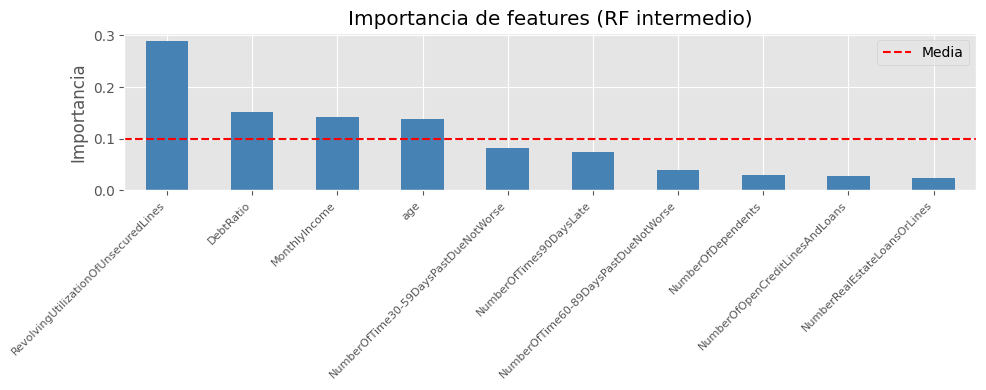

In [14]:
# Entrenamos un RF como modelo intermedio para obtener importancias
rf_inter = RandomForestClassifier(n_estimators=100, random_state=42,
                                  class_weight='balanced', n_jobs=-1)
rf_inter.fit(X_train[features_all], y_train)

importancias = pd.Series(rf_inter.feature_importances_, index=features_all).sort_values(ascending=False)
print("Importancias del RF intermedio:")
print(importancias.round(4))

# Visualizacion
plt.figure(figsize=(10, 4))
importancias.plot(kind='bar', color='steelblue')
plt.axhline(importancias.mean(), color='red', linestyle='--', label='Media')
plt.title("Importancia de features (RF intermedio)")
plt.ylabel("Importancia")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# SelectFromModel con threshold=media para seleccionar las features mas importantes
sfm = SelectFromModel(estimator=rf_inter, threshold='mean', prefit=True)

# Nota: get_feature_names_out() da NotFittedError con prefit=True en algunas versiones de sklearn
# uso get_support() + zip que es compatible con todas las versiones
features_sfm = [f for f, sel in zip(features_all, sfm.get_support()) if sel]
print(f"Features seleccionadas por SelectFromModel (threshold=media): {features_sfm}")
print(f"Total: {len(features_sfm)} features")

# Si hay más de 6, nos quedamos con las top 6 por importancia
if len(features_sfm) > 6:
    features_sfm = importancias.head(6).index.tolist()
    print(f"Hay mas de 6, limitamos a las top 6: {features_sfm}")

lista_3 = features_sfm
print(f"\nLista 3 (SelectFromModel): {lista_3}")

Features seleccionadas por SelectFromModel (threshold=media): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']
Total: 4 features

Lista 3 (SelectFromModel): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']


### 2.4 RFE (Recursive Feature Elimination)

In [16]:
# RFE: elimina features de una en una hasta quedarse con n_features_to_select
rf_rfe = RandomForestClassifier(n_estimators=50, random_state=42,
                                class_weight='balanced', n_jobs=-1)
rfe = RFE(estimator=rf_rfe, n_features_to_select=5, step=1)
rfe.fit(X_train[features_all], y_train)

rfe_ranking = pd.DataFrame({
    'feature': features_all,
    'ranking': rfe.ranking_
}).sort_values('ranking')

print("Ranking RFE (1 = seleccionada, mayor = peor):")
print(rfe_ranking.to_string(index=False))

lista_4 = list(rfe.get_feature_names_out())
print(f"\nLista 4 (RFE): {lista_4}")

Ranking RFE (1 = seleccionada, mayor = peor):
                             feature  ranking
RevolvingUtilizationOfUnsecuredLines        1
                                 age        1
                           DebtRatio        1
                       MonthlyIncome        1
             NumberOfTimes90DaysLate        1
NumberOfTime30-59DaysPastDueNotWorse        2
NumberOfTime60-89DaysPastDueNotWorse        3
                  NumberOfDependents        4
     NumberOfOpenCreditLinesAndLoans        5
        NumberRealEstateLoansOrLines        6

Lista 4 (RFE): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfTimes90DaysLate']


### 2.5 SFS (Sequential Feature Selection)

In [17]:
# SFS: va añadiendo features de una en una buscando la mejor combinacion
# Uso pocos estimadores y cv=3 porque si no tarda muchisimo
rf_sfs = RandomForestClassifier(n_estimators=20, random_state=42,
                                class_weight='balanced', n_jobs=-1)

sfs = SequentialFeatureSelector(
    rf_sfs,
    n_features_to_select=5,
    direction='forward',
    cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1
)

print("Ejecutando SFS (puede tardar un rato)...")
sfs.fit(X_train[features_all], y_train)

lista_5 = list(sfs.get_feature_names_out())
print(f"Lista 5 (SFS): {lista_5}")

Ejecutando SFS (puede tardar un rato)...
Lista 5 (SFS): ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']


### 2.6 Hard Voting

Votos por feature (de 5 posibles):
RevolvingUtilizationOfUnsecuredLines    4
age                                     4
NumberOfTimes90DaysLate                 4
DebtRatio                               3
MonthlyIncome                           3
NumberOfTime30-59DaysPastDueNotWorse    3
NumberOfTime60-89DaysPastDueNotWorse    3
NumberOfOpenCreditLinesAndLoans         1
NumberOfDependents                      1
NumberRealEstateLoansOrLines            0
dtype: int64


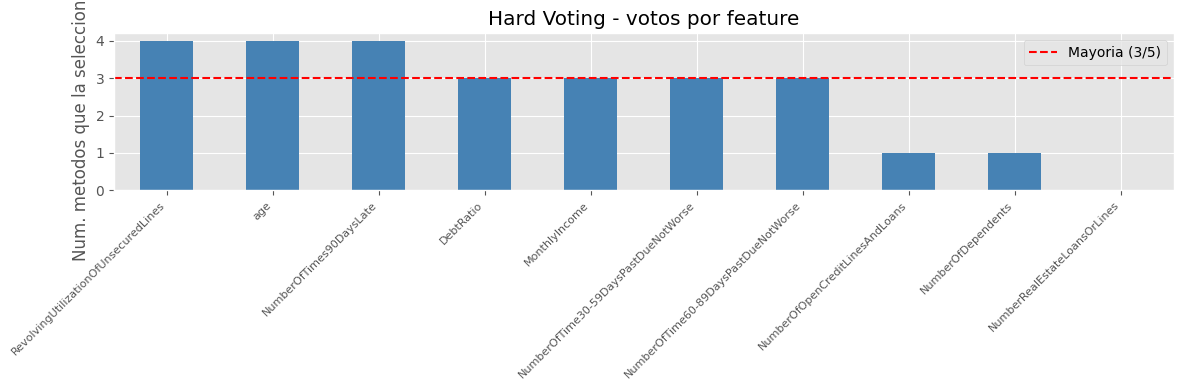


Lista 6 (Hard Voting, top 6): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTimes90DaysLate', 'DebtRatio', 'MonthlyIncome', 'NumberOfTime30-59DaysPastDueNotWorse']


In [18]:
# Contamos cuantos metodos han seleccionado cada feature (hard voting)
# Cada metodo da 1 voto por feature que haya seleccionado

listas_votacion = [lista_1, lista_2, lista_3, lista_4, lista_5]
nombres_votacion = ['Visual+Corr', 'ANOVA+MI', 'SelectFromModel', 'RFE', 'SFS']

votos = {f: 0 for f in features_all}
for lista, nombre in zip(listas_votacion, nombres_votacion):
    for f in lista:
        votos[f] += 1

votos_series = pd.Series(votos).sort_values(ascending=False)

print("Votos por feature (de 5 posibles):")
print(votos_series)

# Visualizacion rapida
votos_series.plot(kind='bar', color='steelblue', figsize=(12, 4))
plt.axhline(3, color='red', linestyle='--', label='Mayoria (3/5)')
plt.title("Hard Voting - votos por feature")
plt.ylabel("Num. metodos que la seleccionaron")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

# Nos quedamos con las 6 mas votadas
lista_6 = votos_series.head(6).index.tolist()
print(f"\nLista 6 (Hard Voting, top 6): {lista_6}")

In [19]:
# Resumen de las 6 listas
listas_todas = {
    'Lista_1_Visual_Corr':   lista_1,
    'Lista_2_ANOVA_MI':      lista_2,
    'Lista_3_SFM':           lista_3,
    'Lista_4_RFE':           lista_4,
    'Lista_5_SFS':           lista_5,
    'Lista_6_Voting':        lista_6
}

print("Resumen de las 6 listas de features:")
for nombre, lista in listas_todas.items():
    print(f"  {nombre:25s} ({len(lista)} features): {lista}")

Resumen de las 6 listas de features:
  Lista_1_Visual_Corr       (6 features): ['NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio']
  Lista_2_ANOVA_MI          (6 features): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse']
  Lista_3_SFM               (4 features): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']
  Lista_4_RFE               (5 features): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfTimes90DaysLate']
  Lista_5_SFS               (5 features): ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']
  Lista_6_Voting            (6 features): ['RevolvingUtilizationO

---
## Paso 3: Comparativa de modelos (18 combinaciones)

Tres modelos x seis listas = 18 medidas en validación cruzada.

Los modelos escogidos son:
- **RandomForestClassifier**: robusto, maneja bien las categoricas como enteros
- **GradientBoostingClassifier**: suele mejorar a RF con los parámetros bien ajustados
- **LogisticRegression**: modelo lineal, lo meto en un Pipeline con StandardScaler porque necesita escalado

In [20]:
# Definimos los 3 modelos
# Para LR uso Pipeline con scaler porque si no los coeficientes no son comparables
modelos = {
    'RandomForest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    ),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ])
}

In [21]:
# 18 comparaciones (esto tarda un rato)
print("Calculando 18 combinaciones modelo x lista de features...")
resultados_18 = []

for nombre_lista, features in listas_todas.items():
    for nombre_modelo, modelo in modelos.items():
        cv_score = np.mean(cross_val_score(
            modelo,
            X_train[features],
            y_train,
            cv=5,
            scoring='balanced_accuracy',
            n_jobs=-1
        ))
        resultados_18.append({
            'lista':          nombre_lista,
            'modelo':         nombre_modelo,
            'cv_bal_acc':     round(cv_score, 4)
        })
        print(f"  {nombre_modelo:20s} | {nombre_lista:25s} -> {cv_score:.4f}")

Calculando 18 combinaciones modelo x lista de features...
  RandomForest         | Lista_1_Visual_Corr       -> 0.5812
  GradientBoosting     | Lista_1_Visual_Corr       -> 0.5948
  LogisticRegression   | Lista_1_Visual_Corr       -> 0.7600
  RandomForest         | Lista_2_ANOVA_MI          -> 0.5802
  GradientBoosting     | Lista_2_ANOVA_MI          -> 0.5946
  LogisticRegression   | Lista_2_ANOVA_MI          -> 0.7608
  RandomForest         | Lista_3_SFM               -> 0.5173
  GradientBoosting     | Lista_3_SFM               -> 0.5186
  LogisticRegression   | Lista_3_SFM               -> 0.7325
  RandomForest         | Lista_4_RFE               -> 0.5809
  GradientBoosting     | Lista_4_RFE               -> 0.5882
  LogisticRegression   | Lista_4_RFE               -> 0.7453
  RandomForest         | Lista_5_SFS               -> 0.7114
  GradientBoosting     | Lista_5_SFS               -> 0.5737
  LogisticRegression   | Lista_5_SFS               -> 0.7429
  RandomForest         | Li

Tabla de resultados CV balanced_accuracy (18 combinaciones):


modelo,GradientBoosting,LogisticRegression,RandomForest
lista,,,
Lista_1_Visual_Corr,0.5948,0.7600,0.5812
Lista_2_ANOVA_MI,0.5946,0.7608,0.5802
Lista_3_SFM,0.5186,0.7325,0.5173
Lista_4_RFE,0.5882,0.7453,0.5809
Lista_5_SFS,0.5737,0.7429,0.7114
Lista_6_Voting,0.5973,0.7534,0.5755


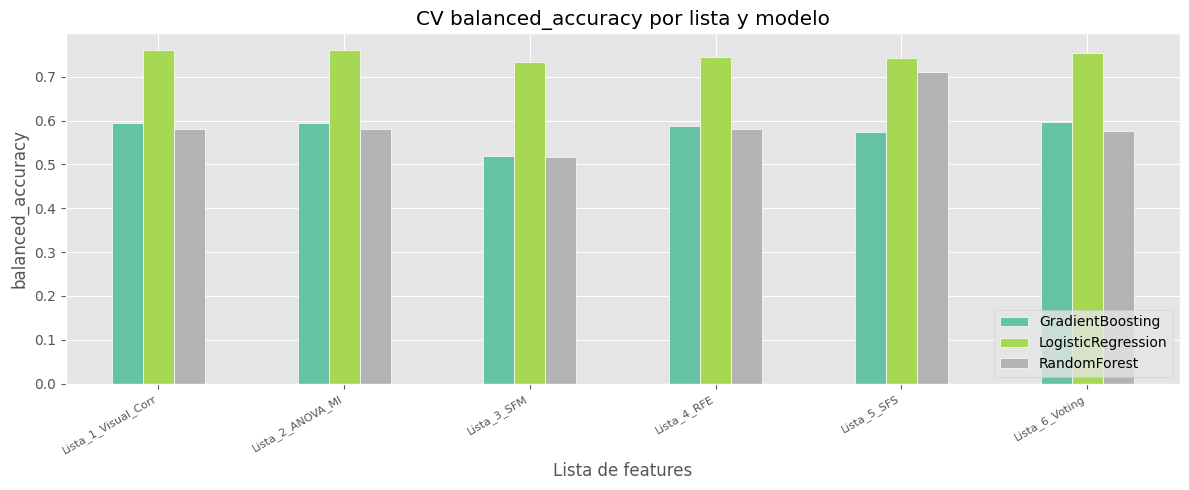


Mejor combinacion:
  Modelo:  LogisticRegression
  Lista:   Lista_2_ANOVA_MI
  CV score: 0.7608


In [22]:
# Resultados en tabla pivot
df_res = pd.DataFrame(resultados_18)
pivot = df_res.pivot(index='lista', columns='modelo', values='cv_bal_acc')

print("Tabla de resultados CV balanced_accuracy (18 combinaciones):")
display(pivot)

# Visualizacion
pivot.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title("CV balanced_accuracy por lista y modelo")
plt.ylabel("balanced_accuracy")
plt.xlabel("Lista de features")
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Mejor combinacion
mejor = df_res.loc[df_res['cv_bal_acc'].idxmax()]
print(f"\nMejor combinacion:")
print(f"  Modelo:  {mejor['modelo']}")
print(f"  Lista:   {mejor['lista']}")
print(f"  CV score: {mejor['cv_bal_acc']:.4f}")

mejor_modelo_nombre = mejor['modelo']
mejor_lista_nombre  = mejor['lista']
best_features = listas_todas[mejor_lista_nombre]

---
## Paso 4: Optimización de hiperparámetros del mejor modelo

In [23]:
print(f"Optimizando hiperparametros de: {mejor_modelo_nombre}")
print(f"Features: {best_features}")

# GridSearch según el modelo que haya ganado
if mejor_modelo_nombre == 'RandomForest':
    modelo_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
    param_grid = {
        'n_estimators':    [50, 100, 200],
        'max_depth':       [5, 10, None],
        'min_samples_leaf': [1, 5, 10]
    }

elif mejor_modelo_nombre == 'GradientBoosting':
    modelo_base = GradientBoostingClassifier(random_state=42)
    param_grid = {
        'n_estimators':  [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 5]
    }

else:  # LogisticRegression
    modelo_base = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ])
    param_grid = {
        'lr__C':       [0.01, 0.1, 1, 10],
        'lr__penalty': ['l1', 'l2'],
        'lr__solver':  ['liblinear']
    }

grid_search = GridSearchCV(
    modelo_base,
    param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train[best_features], y_train)

print(f"\nMejores parametros: {grid_search.best_params_}")
print(f"Mejor CV score:      {grid_search.best_score_:.4f}")

Optimizando hiperparametros de: LogisticRegression
Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse']
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parametros: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Mejor CV score:      0.7607


In [24]:
# Evaluacion final en test
y_pred_test = grid_search.best_estimator_.predict(X_test[best_features])

test_score = balanced_accuracy_score(y_test, y_pred_test)
print(f"=== RESULTADO FINAL EN TEST ===")
print(f"Modelo:            {mejor_modelo_nombre}")
print(f"Features (lista):  {mejor_lista_nombre}")
print(f"Num. features:     {len(best_features)}")
print(f"Balanced accuracy: {test_score:.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=['No default', 'Default']))

=== RESULTADO FINAL EN TEST ===
Modelo:            LogisticRegression
Features (lista):  Lista_2_ANOVA_MI
Num. features:     6
Balanced accuracy: 0.7615

              precision    recall  f1-score   support

  No default       0.97      0.81      0.89      2198
     Default       0.22      0.71      0.34       166

    accuracy                           0.80      2364
   macro avg       0.60      0.76      0.61      2364
weighted avg       0.92      0.80      0.85      2364



### Conclusión

Después de probar los 6 métodos de selección de features y comparar 18 combinaciones (3 modelos x 6 listas), hemos seleccionado el mejor modelo y conjunto de features según la métrica `balanced_accuracy` en validación cruzada.

La métrica `balanced_accuracy` es la adecuada aquí porque el dataset está muy desbalanceado (~7% de defaults), y si usáramos accuracy normal el modelo podría predecir siempre 0 y tener un 93% de aciertos sin aprender nada.

Una observación: las tres features de tipo "PastDue" (días de retraso en pagos) aparecen en casi todas las selecciones, lo cual tiene mucho sentido desde el punto de vista del negocio — si alguien ya ha tenido retrasos anteriores, es más probable que tenga dificultades futuras.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.